In [51]:
import keras

from keras import layers
from keras import ops
from tensorflow_docs.vis import embed
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Input,
    Concatenate,
    Dropout,
    LeakyReLU,
    BatchNormalization,
)
from tensorflow.keras.models import Model
from sklearn.utils import shuffle


## Data loading

In [52]:
X = np.load('data/x_letters.npy')
y = np.load('data/y_letters.npy')

X, y = shuffle(X, y, random_state=42)

X = X[:10000]
y = y[:10000]

num_classes = 26

y = to_categorical(y, num_classes=num_classes)  # One-hot encode labels,



## Data inspection

In [53]:
print(X[0].shape)
print(y.shape)

(28, 28)
(10000, 26)


In [54]:
def number_to_letter(number):
    if 0 <= number <= 25:
        return chr(number + 65)  # ASCII value of 'A' is 65, so we add 65 to the number.
    else:
        return None

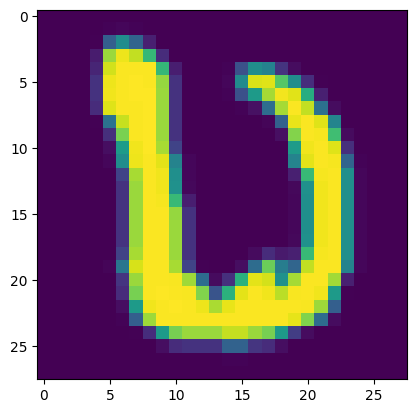

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0.]
U


In [55]:
plt.imshow(X[1])
plt.show()

letter = number_to_letter(np.array(y[1]).argmax())
print(y[1])
print(letter)

## CGAN implementation

## Constants and hyperparams

In [56]:
batch_size = 64
num_channels = 1
num_classes = 26
image_size = 28
latent_dim = 128

We will have to add the number of classes to the input channels of the generator (noise input) as well as the discriminator (generated image input).

## Training the CGAN

In [57]:
class CGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim, num_classes):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.seed_generator = keras.random.SeedGenerator(42)

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, data):
        # Unpack the data (images and their labels)
        real_images, labels = data

        # labels = tf.one_hot(labels, self.num_classes)

        # Sample random points in the latent space
        batch_size = ops.shape(real_images)[0]
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Generate fake images using both noise and labels
        generated_images = self.generator([random_latent_vectors, labels])

        # Combine real and fake images
        combined_images = ops.concatenate([generated_images, real_images], axis=0)

        # Duplicate labels for both fake and real images
        combined_labels = ops.concatenate([labels, labels], axis=0)

        # Assemble labels discriminating real from fake images
        labels_real_fake = ops.concatenate(
            [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0
        )

        # Add random noise to the labels - important trick!
        # basically makes sure the discriminator is not perfect,
        # so that the generator never has a chance to learn
        labels_real_fake += 0.05 * tf.random.uniform(tf.shape(labels_real_fake))

        # Train the discriminator
        for _ in range(3):
            with tf.GradientTape() as tape:
                predictions = self.discriminator([combined_images, combined_labels])
                d_loss = self.loss_fn(labels_real_fake, predictions)

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample new random points in the latent space
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Sample random labels for generator training
        random_labels = tf.random.uniform(
            shape=(batch_size,),
            minval=0,
            maxval=self.num_classes,
            dtype=tf.int32,
            # seed=self.seed_generator,
        )
        random_labels_one_hot = tf.one_hot(random_labels, self.num_classes)

        # Assemble labels that say "all real images"
        misleading_labels = ops.zeros((batch_size, 1))

        # Train the generator
        with tf.GradientTape() as tape:
            fake_images = self.generator([random_latent_vectors, random_labels_one_hot])
            predictions = self.discriminator([fake_images, random_labels_one_hot])
            g_loss = self.loss_fn(misleading_labels, predictions)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [60]:
latent_dim = 32

def build_generator():
    latent_input = Input(shape=(latent_dim,))
    label_input = Input(shape=(num_classes,))

    x = Concatenate()([latent_input, label_input])

    x = Dense(100, activation="relu", kernel_initializer="he_normal")(x)
    x = Dense(150, activation="relu", kernel_initializer="he_normal")(x)

    x = Dense(28 * 28, activation="sigmoid")(x)
    generator_output = layers.Reshape((28, 28))(x)

    return tf.keras.Model([latent_input, label_input], generator_output)


def build_discriminator():
    image_input = Input(shape=(28, 28))
    label_input = Input(shape=(num_classes,))
    flat_image = Flatten()(image_input)

    x = Concatenate()([flat_image, label_input])

    x = Dense(1024, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(512, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(256, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    real_or_fake = Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], real_or_fake)


generator = build_generator()
discriminator = build_discriminator()

# CGAN
cgan = CGAN(discriminator, generator, latent_dim=latent_dim, num_classes=num_classes)
cgan.compile(
    d_optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    g_optimizer=keras.optimizers.RMSprop(learning_rate=0.005), # g_optimizer=keras.optimizers.RMSprop(learning_rate=0.002),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

cgan.fit(X, y, epochs=50)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - d_loss: 0.7734 - g_loss: 2.3598
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - d_loss: 0.5028 - g_loss: 2.3346
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - d_loss: 0.4578 - g_loss: 2.4257
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - d_loss: 0.4694 - g_loss: 2.2594
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - d_loss: 0.4525 - g_loss: 2.2245
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - d_loss: 0.4723 - g_loss: 2.0591
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - d_loss: 0.5049 - g_loss: 1.8637
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - d_loss: 0.5217 - g_loss: 1.6949
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - d_loss: 0.5221 - g_loss: 1.6344
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - d_loss: 0.5144 - g_loss: 1.6495
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - d_loss: 0.5092 - g_loss: 1.6464
Epoch 12/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

## Simon Test Generaton and Discriminator

In [32]:
latent_dim = 32

def build_generator():
    latent_input = Input(shape=(latent_dim,))
    label_input = Input(shape=(num_classes,))

    x = Concatenate()([latent_input, label_input])

    x = Dense(256, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Dense(512, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Dense(1024, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Dense(28 * 28, activation="tanh")(x)
    generator_output = layers.Reshape((28, 28))(x)

    return tf.keras.Model([latent_input, label_input], generator_output)


def build_discriminator():
    image_input = Input(shape=(28, 28))
    label_input = Input(shape=(num_classes,))
    flat_image = Flatten()(image_input)

    x = Concatenate()([flat_image, label_input])
    
    x = Dense(1024, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(512, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(256, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    real_or_fake = Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], real_or_fake)


generator = build_generator()
discriminator = build_discriminator()

# CGAN
cgan = CGAN(discriminator, generator, latent_dim=latent_dim, num_classes=num_classes)
cgan.compile(
    d_optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    g_optimizer=keras.optimizers.RMSprop(learning_rate=0.002),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

cgan.fit(X, y, epochs=20)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - d_loss: 0.5306 - g_loss: 42.5316
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - d_loss: -77.7295 - g_loss: 8810.7139
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - d_loss: -1019.6895 - g_loss: 103380.2891
Epoch 4/20
 85/313 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - d_loss: -4387.1216 - g_loss: 409709.5625

KeyboardInterrupt: 

Here we tried some of the techniques advised for the **Deep Convolutional Gans**, but the discriminator was just superior, this meant that we had to look into how to improve the generator's performance.

## Trying to improve the generator

In [47]:
latent_dim = 128

def build_generator():
    latent_input = Input(shape=(latent_dim,))
    label_input = Input(shape=(num_classes,))

    x = Concatenate()([latent_input, label_input])

    x = Dense(256, activation="relu", kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)

    x = Dense(512, activation="relu", kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)

    x = Dense(1024, activation="relu", kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)

    x = Dense(28 * 28, activation="sigmoid")(x)
    generator_output = layers.Reshape((28, 28))(x)

    return tf.keras.Model([latent_input, label_input], generator_output)


def build_discriminator():
    image_input = Input(shape=(28, 28))
    label_input = Input(shape=(num_classes,))
    flat_image = Flatten()(image_input)

    x = Concatenate()([flat_image, label_input])
    
    x = Dense(1024, activation="relu", kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(512, activation="relu", kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(256, activation="relu", kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    real_or_fake = Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], real_or_fake)


generator = build_generator()
discriminator = build_discriminator()

# CGAN
cgan = CGAN(discriminator, generator, latent_dim=latent_dim, num_classes=num_classes)
cgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0005, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

X = X / 255.0

cgan.fit(X, y, epochs=4)

Epoch 1/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - d_loss: 0.2178 - g_loss: 10.1460
Epoch 2/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - d_loss: -21.1230 - g_loss: 1712.0388
Epoch 3/4
 82/313 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - d_loss: -699.1087 - g_loss: 55807.9727

KeyboardInterrupt: 

While trying to improve the generator we noticed that the CGAN is very unstable and that we often get mode collapse if we try to improve the generator. Therefore we decided to look more into how to stabilize the network to prevent mode collapses.

---

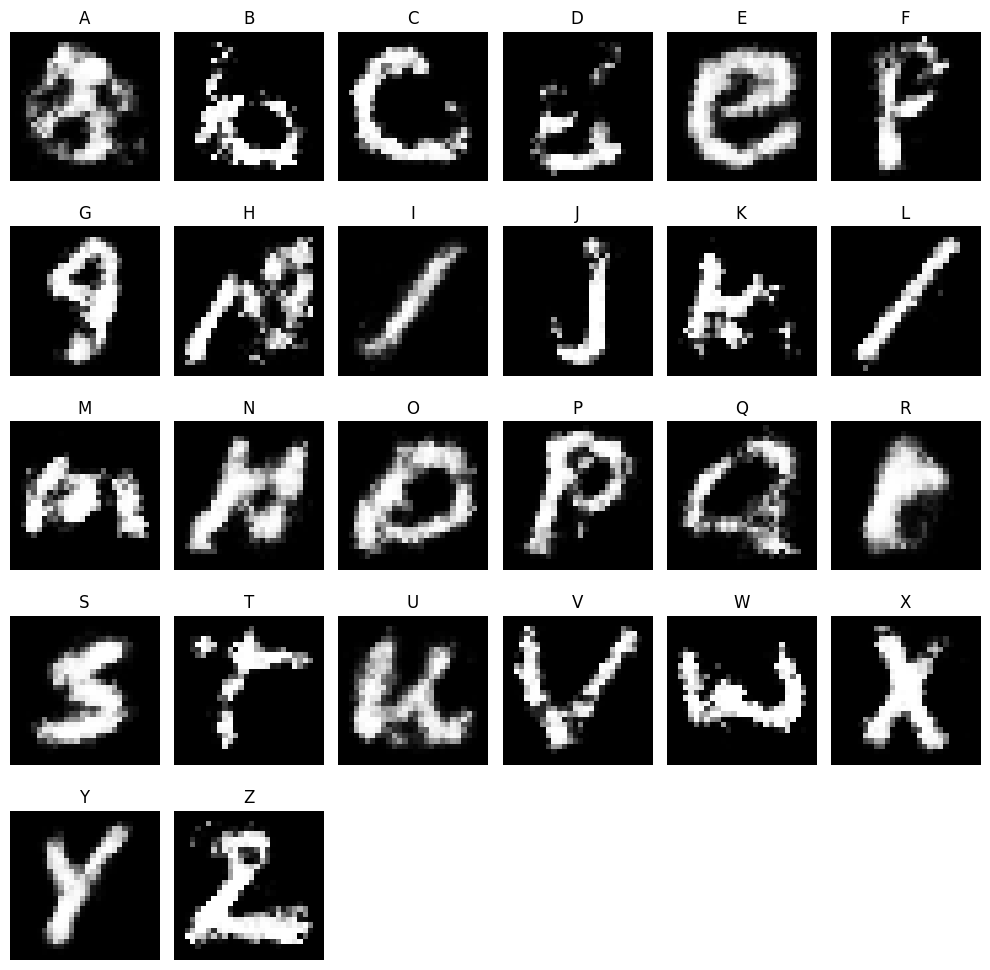

In [61]:
# Define a function to generate an image for a given letter (class index)
def generate_letter(generator, letter_index, latent_dim):
    # 1. Generate a random latent vector
    random_latent_vector = tf.random.normal(shape=(1, latent_dim))

    # 2. Create a one-hot encoded label for the letter (e.g., 'A' -> index 0)
    label = tf.one_hot([letter_index], num_classes)

    # 3. Generate the image using the generator
    generated_image = generator([random_latent_vector, label])

    # 4. Reshape the generated image
    generated_image = generated_image.numpy().reshape(28, 28)

    return generated_image


# Generate all letters (A-Z) in a grid
def plot_all_letters(generator, latent_dim):
    plt.figure(figsize=(10, 10))  # Create a figure for 26 subplots (5x6 grid)

    for i in range(26):
        plt.subplot(5, 6, i + 1)  # Create a 5x6 grid of subplots
        generated_image = generate_letter(
            generator, letter_index=i, latent_dim=latent_dim
        )
        plt.imshow(generated_image, cmap="gray")
        plt.title(chr(i + ord("A")))  # Convert index back to letter (A, B, C, etc.)
        plt.axis("off")  # Turn off axis labels for a cleaner look

    plt.tight_layout()  # Adjust subplots to fit into the figure area
    plt.show()


# Alphabet according to the generator 🤖
plot_all_letters(generator, latent_dim)

In [30]:
def plot_string(string, generator, latent_dim):
    plt.figure(figsize=(15, 5))
    string = string.upper()

    for i, letter in enumerate(string):
        plt.subplot(1, len(string), i + 1)
        generated_image = generate_letter(
            generator, letter_index=ord(letter) - ord("A"), latent_dim=latent_dim
        )
        plt.subplots_adjust(wspace=0, hspace=0)
        plt.imshow(generated_image, cmap="gray_r")
        # plt.title(letter)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

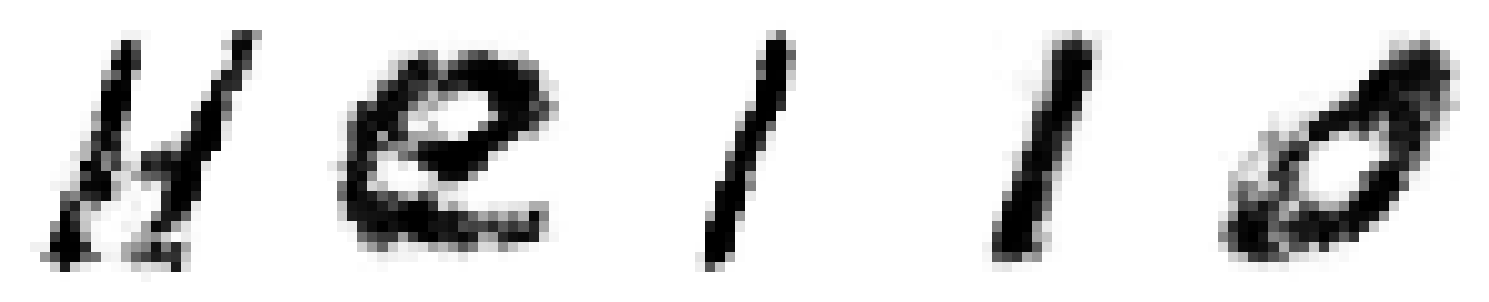

In [62]:
plot_string("HELLO", generator, latent_dim)